In [ ]:
# install gensim
!pip install gensim

In [ ]:
from google.colab import files
src = list(files.upload().values())[0]
open('utils.py','wb').write(src)

Saving utils.py to utils.py


2755

In [ ]:
# import libraries
import json
from collections import Counter
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
import utils

## Load and view data

In [ ]:
# load and display data
with open('/content/sample_data/countries.json', 'r') as fout:
    countries = json.load(fout)

In [ ]:
countries['India'][:20]

['India',
 'Hindi',
 'Bhārat',
 'officially',
 'the',
 'Republic',
 'of',
 'India',
 'Hindi',
 'Bhārat',
 'Gaṇarājya',
 'is',
 'a',
 'country',
 'in',
 'South',
 'Asia',
 'It',
 'is',
 'the']

In [ ]:
# print first 512 words from Wiki of India
print(' '.join(countries['India'])[:512] + ' ...')

India Hindi Bhārat officially the Republic of India Hindi Bhārat Gaṇarājya is a country in South Asia It is the second most populous country the seventh largest country by land area and the most populous democracy in the world Bounded by the Indian Ocean on the south the Arabian Sea on the southwest and the Bay of Bengal on the southeast it shares land borders with Pakistan to the west China Nepal and Bhutan to the north and Bangladesh and Myanmar to the east In the Indian Ocean India is in the vicinity of  ...


## Basic `Word2Vec` usage

In [ ]:
# basic word2vec usage
model = Word2Vec(sentences=countries.values())

In [ ]:
# 5 most similar word to India, learnt by the model
model.wv.most_similar('India', topn=5)

[('Brazil', 0.8286747336387634),
 ('China', 0.8105413317680359),
 ('Turkey', 0.7652761340141296),
 ('Iran', 0.7619249224662781),
 ('Mozambique', 0.751375675201416)]

In [ ]:
# enable computation of loss
model = Word2Vec(
    sentences=countries.values(),
    compute_loss=True
)
model.get_latest_training_loss()

5126940.5

## Heuristics for `Word2Vec` algorithms

In [ ]:
# How many unique words in the vocabulary?
counter = Counter()
for words in countries.values():
    for word in words:
        counter.update([word])

print(len(counter))

85125


In [ ]:
# default vocabulary size of the original model
len(model.wv)

21092

Loss after epoch 0: 1281984.625
Loss after epoch 1: 976268.875
Loss after epoch 2: 947464.75
Loss after epoch 3: 904953.25
Loss after epoch 4: 764220.5
Loss after epoch 5: 786094.0
Loss after epoch 6: 717412.0
Loss after epoch 7: 628876.5
Loss after epoch 8: 716911.0
Loss after epoch 9: 689724.5


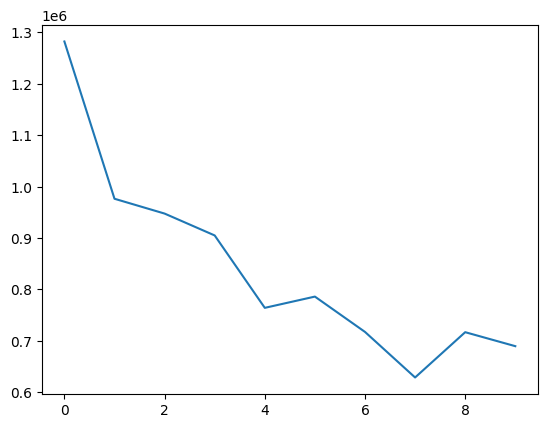

In [ ]:
# Retrain - increased vocabulary size, more epochs, larger word vectors
metric = utils.MetricCallback(every=1)
model = Word2Vec(
    sentences=countries.values(),
    vector_size=128,
    epochs=10,
    max_vocab_size=65536,
    compute_loss=True,
    callbacks=[metric]
)
plt.plot(metric.myloss)

In [ ]:
# check again the similar words to India
model.wv.most_similar('India', topn=5)

[('China', 0.7293248772621155),
 ('Pakistan', 0.6147268414497375),
 ('Vietnam', 0.5956546664237976),
 ('Indonesia', 0.5939428806304932),
 ('Asia', 0.5817035436630249)]

Loss after epoch 0: 474530.75
Loss after epoch 10: 234166.75
Loss after epoch 20: 211419.0
Loss after epoch 30: 192114.5
Loss after epoch 40: 176772.0
Loss after epoch 50: 163244.0
Loss after epoch 60: 159369.0
Loss after epoch 70: 180063.0
Loss after epoch 80: 150392.0
Loss after epoch 90: 113856.0


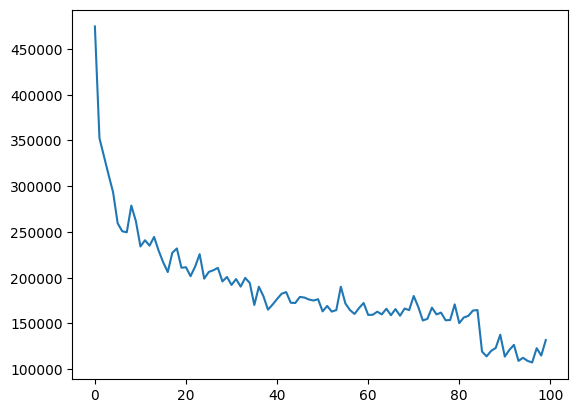

In [ ]:
# Retrain - more epochs
metric = utils.MetricCallback(every=10)
model = Word2Vec(
    sentences=countries.values(),
    vector_size=128,
    epochs=100,
    max_vocab_size=65536,
    compute_loss=True,
    callbacks=[metric],
    min_alpha=0.001,
    workers=9
)
plt.plot(metric.myloss)

In [ ]:
model.wv.most_similar('India')

[('Nepal', 0.5899757742881775),
 ('China', 0.572218120098114),
 ('Pakistan', 0.5655296444892883),
 ('Singapore', 0.5547892451286316),
 ('Bangladesh', 0.5381187200546265),
 ('Vietnam', 0.5032203197479248),
 ('Oman', 0.4977971911430359),
 ('Japan', 0.49378183484077454),
 ('Bengal', 0.4815117418766022),
 ('Indian', 0.4781178832054138)]

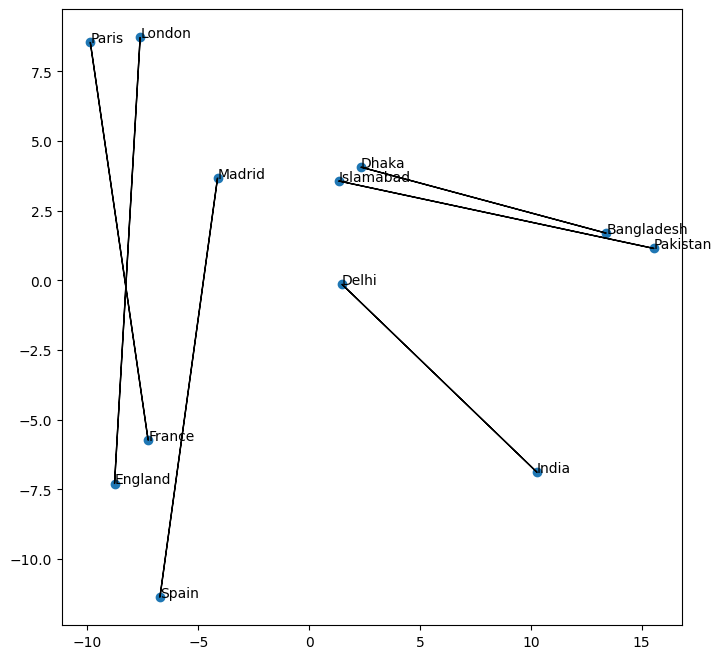

In [ ]:
# examine the vector space
X = ['India', 'Pakistan', 'Bangladesh', 'France', 'England', 'Spain']
Y = ['Delhi', 'Islamabad', 'Dhaka', 'Paris', 'London', 'Madrid']
utils.plot_arrows(X, Y, model.wv)

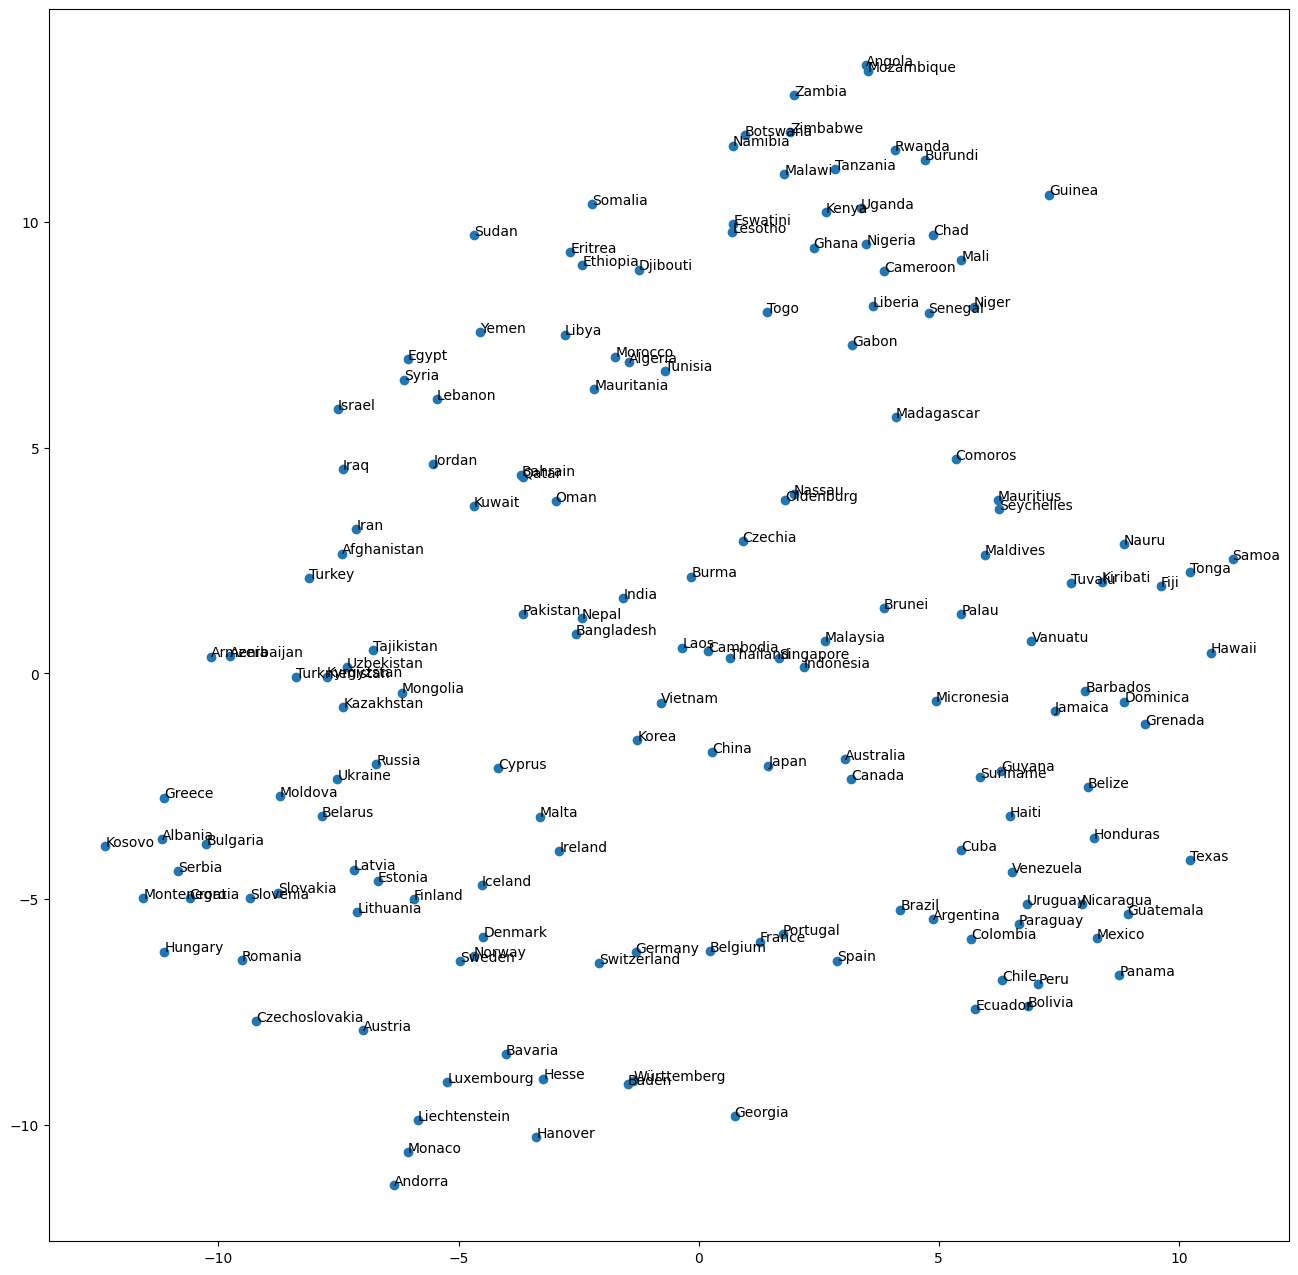

In [ ]:
# visualize vectors for all countries
utils.plot_vectors(countries, model)

## Word analogies

In [ ]:
# India: Hindi -> Germany: __ ?
model.wv.most_similar(positive=['Hindi', 'Germany'], negative=['India'])

[('German', 0.5039339065551758),
 ('Liszt', 0.420228511095047),
 ('Archduke', 0.4055408835411072),
 ('Karl', 0.39764901995658875),
 ('Georg', 0.3972489833831787),
 ('Gerhard', 0.39584940671920776),
 ('Titoist', 0.391471266746521),
 ('Edvard', 0.39003226161003113),
 ('Sándor', 0.38883501291275024),
 ('Austrians', 0.3880757987499237)]

In [ ]:
# save the model
model.save('wiki-countries.w2v')

In [ ]:
# load model again
from gensim.models import KeyedVectors
model = KeyedVectors.load('wiki-countries.w2v')

In [ ]:
model